In [1]:
import sys
sys.path.append('/home/gluo/mitax')

import os
os.environ['CUDA_DEVICE_ORDER']='PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES']='1'

import numpy as np
import jax.numpy as jnp
from functools import partial
import jax

from mitax.misc import utils
from mitax.mri import ops
from mitax.sampler import AncestralSampler
from utils import *


In [2]:


def prepare_simu(config):
        
    kspace = np.squeeze(np.load(config['ksp_path'])['kspace'])

    nx, ny, _ = kspace.shape
    coilsen = np.squeeze(utils.bart(1, 'ecalib -m1 -r20 -c0.001', kspace[np.newaxis, ...]))
    img_shape = [nx, ny]
    std_coils = ops.mifft2(kspace, img_shape)

    rss = np.sum(np.multiply(std_coils, np.squeeze(np.conj(coilsen))), axis=2)
    mask = utils.bart(1, 'poisson -Y %d -Z %d -y %f -z %f -s 1234 -v -C %d'%(nx, ny, config['fx'], config['fy'], config['cal']))
    mask = np.squeeze(mask)

    und_ksp = kspace*abs(mask[..., np.newaxis])

    coilsen = np.squeeze(utils.bart(1, 'ecalib -m1 -r20 -c0.001', und_ksp[np.newaxis, ...]))
    coilsen = np.squeeze(coilsen)
    x_ = ops.AT_cart(und_ksp, coilsen, mask, img_shape)

    return x_, mask, coilsen, (nx, ny), rss, und_ksp


In [3]:
config={
    'ksp_path': '/home/gluo/brain_mat/test/hku_100140.npz',
    'fx': 2.3,
    'fy': 2.3,
    'cal': 20,
    'nx': 256,
    'ny': 256,
}

zero_filled, mask, coilsen, shape, rss, und_ksp = prepare_simu(config)
zero_filled = zero_filled/np.max(abs(zero_filled)) # [-1, 1]
und_ksp     = und_ksp/np.max(abs(zero_filled)) # [-1, 1]
l1_recon    = utils.bart(1, 'pics -l1 -r 0.01', und_ksp[:,:,np.newaxis,:], coilsen[:,:,np.newaxis,:])

und_ksp = np.squeeze(und_ksp)[np.newaxis, ...]
coilsen = np.squeeze(coilsen)[np.newaxis, ...]
mask    = np.squeeze(mask)[np.newaxis, ...]

grad_params = {'coilsen': coilsen, 'mask': mask, 'shape': [256, 256], 'axis': (1,2)}
AHA         = partial(ops.AHA, **grad_params)

bart ecalib -m1 -r20 -c0.001 /tmp/tmpem1elxgein0 /tmp/tmpem1elxgeout0
Done.
bart poisson -Y 256 -Z 256 -y 2.300000 -z 2.300000 -s 1234 -v -C 20  /tmp/tmp3fcsjvq1out0
points: 5883, grid size: 256x256 = 65536 (R = 11.139894)
bart ecalib -m1 -r20 -c0.001 /tmp/tmpisdfxxrrin0 /tmp/tmpisdfxxrrout0
Done.
bart pics -l1 -r 0.01 /tmp/tmpudpmzofrin0 /tmp/tmpudpmzofrin1 /tmp/tmpudpmzofrout0
Size: 65536 Samples: 5882 Acc: 11.14
l1-wavelet regularization: 0.010000
Regularization terms: 1, Supporting variables: 0
FISTA
Total Time: 0.844898


In [4]:
if True:
    logdir='/home/gluo/mitax/examples/log/20240110-201054'
    config = utils.load_config(logdir+'/config.yaml')

    sampler = AncestralSampler(net_name  = config['net_name'],
                           net_hparams   = config['net_hparams'],
                           dm_name       = config['loss_name'],
                           dm_hparams    = config['loss_params'],
                           target_snr    = 0.2,
                           init_input    = {'x': jnp.ones((1, 256, 256, 2), dtype=jnp.float32), 't': jnp.ones((1), dtype=jnp.float32)},
                           path          = logdir+'/mitax.model.unet.ncsnpp_999')

if False:
    logdir='/home/gluo/mitax/examples/log/20240109-160634'
    config = utils.load_config(logdir+'/config.yaml')

    sampler = AncestralSampler(net_name      = config['net_name'],
                            net_hparams   = config['net_hparams'],
                            dm_name       = config['loss_name'],
                            dm_hparams    = config['loss_params'],
                            target_snr    = 0.2,
                            init_input    = {'x': jnp.ones((1, 256, 256, 2), dtype=jnp.float32), 't': jnp.ones((1), dtype=jnp.float32)},
                            path          = logdir+'/mitax.model.unet.ncsnpp_999')



In [11]:
step_size = 1
@jax.jit
def cond_func(x, sig):
    x = utils.float2cplx(x)
    x =  x + step_size*(zero_filled - AHA(x))
    x = utils.cplx2float(x)
    return x

sampler.cond_func = cond_func
sampler.dm.continuous = True
sampler.dm.N = 1000
sampler.dm.sigma_max = 10.
sampler.dm.sigma_min = 0.005
sampler.dm.sigma_type = 'rho_p'
sampler.dm.rho = 7
input_shape = (10, 256, 256, 2)
sampler.create_functions()

_, image1 = sampler(jax.random.normal(jax.random.PRNGKey(4), input_shape)*sampler.dm.sigma_max, inner_steps=1)

100%|██████████| 1000/1000 [03:49<00:00,  4.36it/s]


In [6]:
savecfl('recon', image1[-1])
savecfl('coilcomb', rss)
savecfl('zero_filled', np.array(zero_filled))
savecfl('l1_recon', np.array(l1_recon))
savecfl('und_ksp', np.array(und_ksp))
savecfl('coilsen', np.array(coilsen))

In [7]:
import cv2
import cmapy
import matplotlib.pyplot as plt
%matplotlib inline

import scipy.stats

def mean_confidence_interval(std, confidence=0.95, N=10):
    se = std/np.sqrt(N-1)   # standard error. Since data size is 10 and we compute std with ddof=0, here we use sqrt(N-1)
    h = se * scipy.stats.t.ppf((1+confidence)/2., N-1)
    return h

GRAY2RGB   = lambda x : cv2.cvtColor(x, cv2.COLOR_GRAY2RGB)
FLOAT2GRAY = lambda x, exposure_factor=1.0 : np.uint8(x/np.max(x) * 255.* exposure_factor)
GRAY2COLOR = lambda x, name : cv2.applyColorMap(x, cmapy.cmap(name))
BGR2RGB    = lambda x : cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
GBLUR      = lambda x, ksize, sigma : cv2.GaussianBlur(x, ksize, sigma)
def CUT_OFF(x, th):
    x[x<th] = 0
    return x

exposure_factor = 9
weight          = 0.1
colormap        = 'jet'
threshold       = 250
ksize           = (5,5)
sigma           = 8

def fusion(mmse_, var_):
    mmse_gray   = FLOAT2GRAY(abs(mmse_))
    mmse_rgb    = GRAY2RGB(abs(mmse_gray))
    var         = FLOAT2GRAY(abs(var_), exposure_factor*np.max(abs(var_)))
    var_color   = BGR2RGB(GRAY2COLOR(var, colormap))
    var_color   = CUT_OFF(var_color, threshold)
    var_color   = GBLUR(var_color, ksize, sigma)
    fusion_mmse = (1.0-weight) * mmse_rgb + weight*var_color

    return var_color, fusion_mmse, mmse_rgb

def hard_fusion(m, v):
    return fusion(m, v)

def soft_fusion(m, v, confidence=0.95, N=10):
    interval = mean_confidence_interval(abs(v), confidence, N)
    return fusion(m, interval)


def plot_fusion(var_c, err, fusion_m, rgb_m, coil_comb, name):
    plt.figure(figsize=(20, 4))
    plt.subplot(1, 5, 1)
    plt.imshow(var_c)
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(err, cmap='viridis', vmin=0, vmax=0.1)
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.imshow(np.uint8(fusion_m))
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(rgb_m)
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.imshow(coil_comb)
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(name)

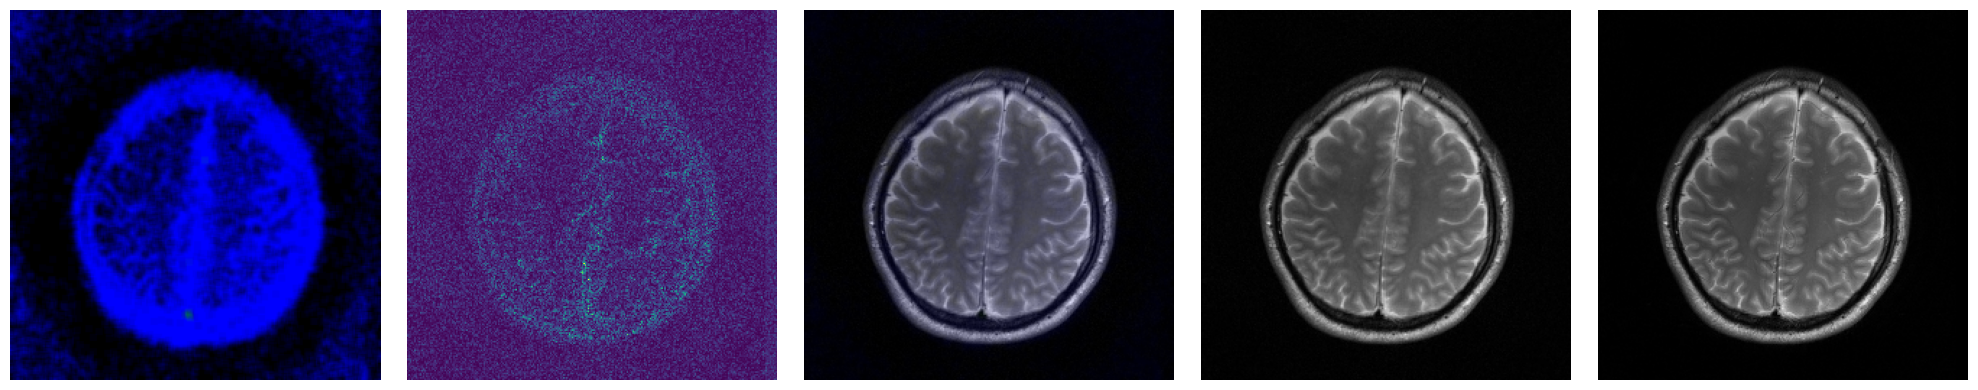

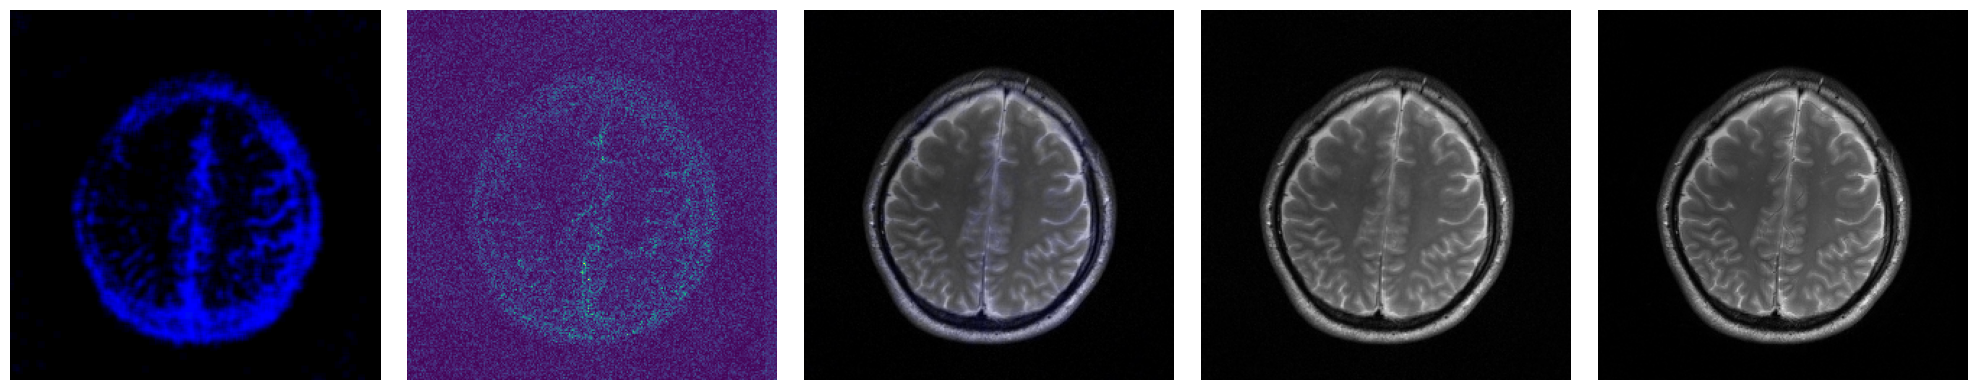

In [12]:
recon = utils.float2cplx(image1)
recon_mmse         = np.mean(recon, axis=0)
recon_var          = np.std(recon, axis=0)
coil_comb          = rss

err         = abs(abs(recon[0])/np.max(abs(recon[0])) - abs(coil_comb)/np.max(abs(coil_comb)))
#err         = FLOAT2GRAY(err)
#err         = GRAY2RGB(err)

coil_comb   = FLOAT2GRAY(abs(coil_comb))
coil_comb   = GRAY2RGB(abs(coil_comb))

var_c, fusion_m, rgb_m = hard_fusion(recon_mmse, recon_var)
plot_fusion(var_c, err, fusion_m, rgb_m, coil_comb, '10x_hard.pdf')

var_c, fusion_m, rgb_m = soft_fusion(recon_mmse, recon_var)
plot_fusion(var_c, err, fusion_m, rgb_m, coil_comb, '10x_soft.pdf')